<a href="https://colab.research.google.com/github/HyperactiveHypno/Argus/blob/main/Nasa_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install lightkurve
!pip install astroquery

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 77.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 132.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 255.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 223.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 191.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 142.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 1.2 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=c42afa0b784f30b57589b8be8584303ffccfb227ce085bba3f0924c2eaa1295b
  Stored in directory: /root/.cache/pip/wheels/04/15/cd/2f622795b09e83471a3be5d2581cd9cf96a6ec7aa78e8deffe
  Created wheel for memoiza

In [3]:
import numpy as np
import lightkurve as lk
import pandas as pd
from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
/tmp/ipykernel_1287/2842100690.py:4: DeprecationWarning: the ``nasa_exoplanet_archive`` module has been moved to astroquery.ipac.nexsci.nasa_exoplanet_archive, please update your imports.
  from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive


In [ ]:
result = lk.search_lightcurve("Kepler-10", mission="Kepler")
print(result)

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


SearchResult containing 50 data products.

 #       mission      year   author   exptime         target_name          distance
                                         s                                  arcsec 
--- ----------------- ---- ---------- ------- ---------------------------- --------
  0 Kepler Quarter 02 2009     Kepler      60                kplr011904151      0.0
  1 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  2 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  3 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  4 Kepler Quarter 00 2009     Kepler    1800                kplr011904151      0.0
  5 Kepler Quarter 01 2009     Kepler    1800                kplr011904151      0.0
  6 Kepler Quarter 02 2009     Kepler    1800                kplr011904151      0.0
  7 Kepler Quarter 03 2009     Kepler    1800                kplr011904151      0.0
  8 Kepler Quarter 07 2010     Ke

/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 5 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

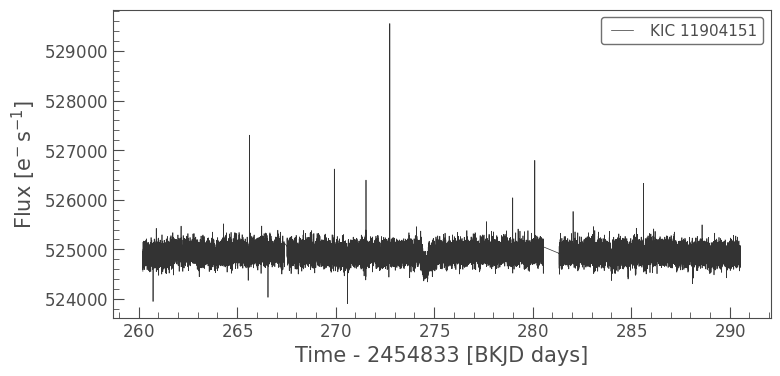

In [ ]:
# Download one quarter of data
lc = lk.search_lightcurve("Kepler-10", mission="Kepler", quarter=3).download()

# Plot it
lc.plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

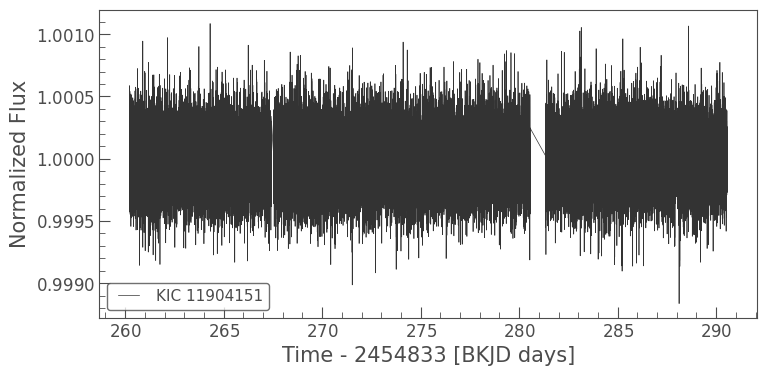

In [ ]:
# Clean the data and flatten it
lc_clean = lc.remove_outliers().flatten()
lc_clean.plot()

<Axes: xlabel='Frequency [$\\mathrm{\\frac{1}{d}}$]', ylabel='Power'>

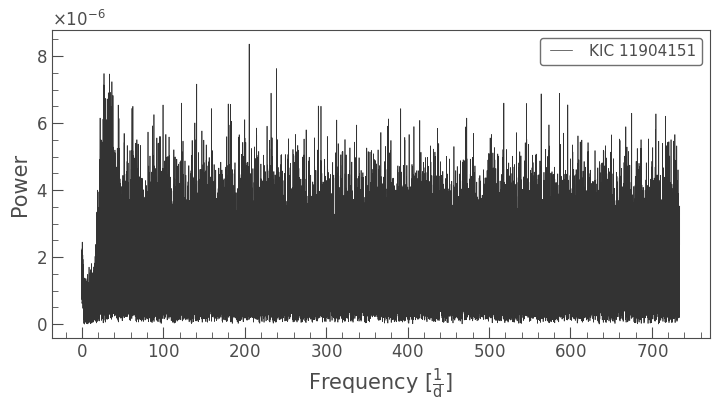

In [ ]:
# Find the period of the planet's orbit
pg = lc_clean.to_periodogram()
pg.plot()

Best period: 14.467000000000013 d


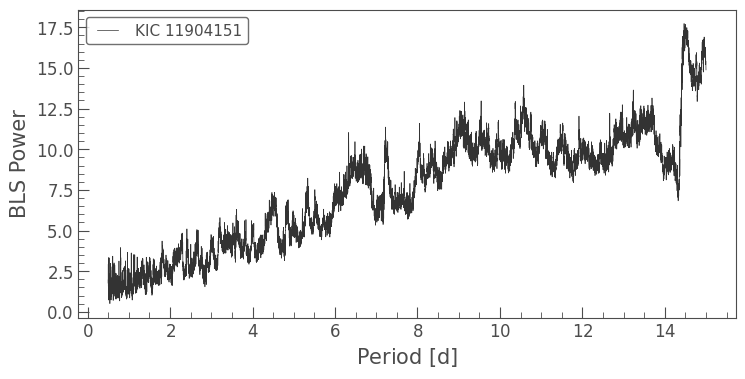

In [ ]:
# Use Box Least Squares - best method for finding planet transits
pg = lc_clean.to_periodogram(method='bls', period=np.arange(0.5, 15, 0.001))
pg.plot()

# Print the best period found
best_period = pg.period_at_max_power
print(f"Best period: {best_period}")

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

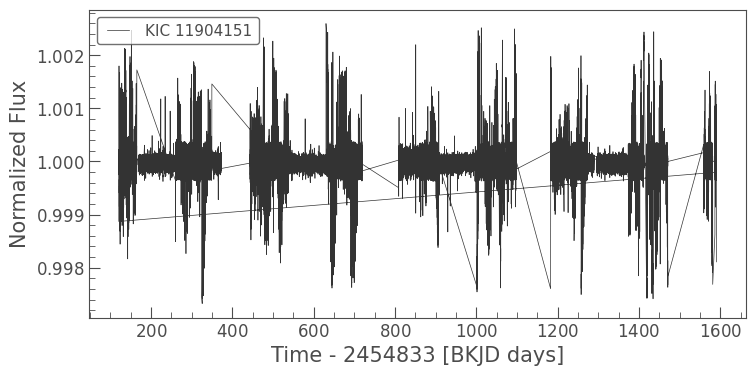

In [ ]:
# Download ALL quarters of Kepler-10 data and stitch together
lc_all = lk.search_lightcurve("Kepler-10", mission="Kepler",
                               cadence="long").download_all().stitch()

# Clean and flatten
lc_all_clean = lc_all.remove_outliers().flatten()
lc_all_clean.plot()

`period` contains 8360719 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Best period: 1.6750000000000012 d


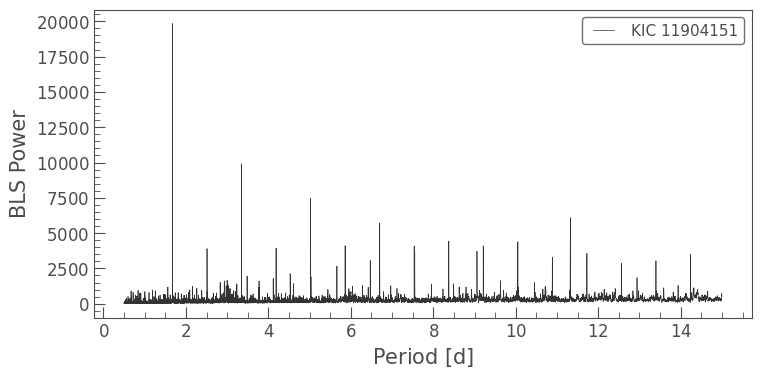

In [ ]:
# Now run BLS on full 4 years of data
pg2 = lc_all_clean.to_periodogram(method='bls',
                                   period=np.arange(0.5, 15, 0.001))
pg2.plot()
print(f"Best period: {pg2.period_at_max_power}")

`period` contains 7207485 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Best period: 0.8374999999999628 d


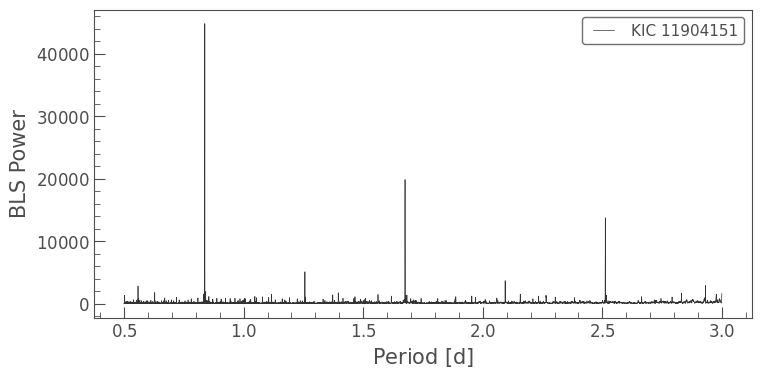

In [ ]:
# Narrow search to short periods only
pg3 = lc_all_clean.to_periodogram(method='bls',
                                   period=np.arange(0.5, 3, 0.0001))
pg3.plot()
print(f"Best period: {pg3.period_at_max_power}")

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

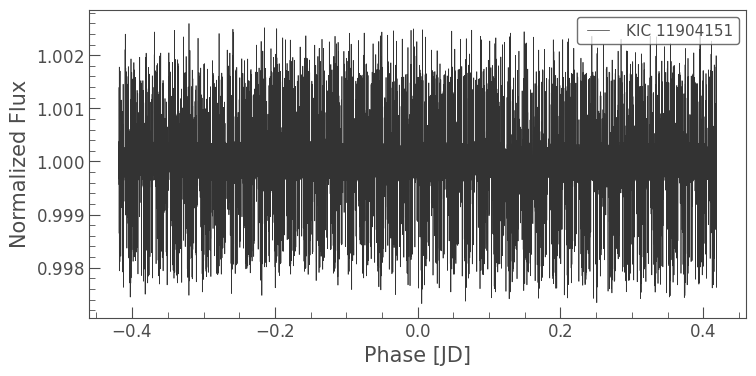

In [ ]:
# Fold the light curve at the best period
folded = lc_all_clean.fold(period=pg3.period_at_max_power)
folded.plot()

In [4]:
from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive
import pandas as pd

# Download Kepler cumulative KOI catalog
koi = NasaExoplanetArchive.query_criteria(table="cumulative", select="*")
df = koi.to_pandas()

print(f"Total stars: {len(df)}")
print(df['koi_disposition'].value_counts())

Total stars: 9564
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64


In [5]:
# Keep only confirmed and false positives
df_clean = df[df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])]

# Convert to binary labels
df_clean = df_clean.copy()
df_clean['label'] = (df_clean['koi_disposition'] == 'CONFIRMED').astype(int)

print(f"Confirmed planets: {df_clean['label'].sum()}")
print(f"False positives: {(df_clean['label'] == 0).sum()}")
print(df_clean[['kepid', 'koi_disposition', 'label']].head(10))

Confirmed planets: 2746
False positives: 4839
       kepid koi_disposition  label
0   10797460       CONFIRMED      1
1   10797460       CONFIRMED      1
3   10848459  FALSE POSITIVE      0
4   10854555       CONFIRMED      1
5   10872983       CONFIRMED      1
6   10872983       CONFIRMED      1
7   10872983       CONFIRMED      1
8    6721123  FALSE POSITIVE      0
9   10910878       CONFIRMED      1
10  11446443       CONFIRMED      1


In [6]:
df_clean.head()

,kepid,kepoi_name,kepler_name,ra,ra_err,ra_str,dec,dec_err,dec_str,koi_gmag,...,koi_insol_err1,koi_insol_err2,koi_srho,koi_srho_err1,koi_srho_err2,koi_fittype,koi_score,sky_coord.ra,sky_coord.dec,label
0,10797460,K00752.01,Kepler-227 b,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,...,29.45,-16.65,3.20796,0.33173,-1.09986,LS+MCMC,1.000,291.93423,48.141651,1
1,10797460,K00752.02,Kepler-227 c,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,...,2.87,-1.62,3.02368,2.20489,-2.49638,LS+MCMC,0.969,291.93423,48.141651,1
3,10848459,K00754.01,,285.53461,0.0,19h02m08.31s,48.285210,0.0,+48d17m06.8s,16.100,...,668.95,-230.35,0.22080,0.00917,-0.01837,LS+MCMC,0.000,285.53461,48.285210,0
4,10854555,K00755.01,Kepler-664 b,288.75488,0.0,19h15m01.17s,48.226200,0.0,+48d13m34.3s,16.015,...,874.33,-314.24,1.98635,2.71141,-1.74541,LS+MCMC,1.000,288.75488,48.226200,1
5,10872983,K00756.01,Kepler-228 d,296.28613,0.0,19h45m08.67s,48.224670,0.0,+48d13m28.8s,16.234,...,112.85,-36.70,0.67324,0.33286,-0.38858,LS+MCMC,1.000,296.28613,48.224670,1


In [7]:
# These are the features already in the catalog
# No need to download 7000 light curves yet!
features = [
    'koi_period',      # orbital period
    'koi_depth',       # how deep the transit dip is
    'koi_duration',    # how long the transit lasts
    'koi_prad',        # planet radius estimate
    'koi_teq',         # planet temperature
    'koi_insol',       # stellar flux
    'koi_steff',       # star temperature
    'koi_slogg',       # star surface gravity
    'koi_srad',        # star radius
]

X = df_clean[features].copy()
y = df_clean['label'].copy()

# Check for missing values
print(X.isnull().sum())
print(f"\nDataset shape: {X.shape}")

koi_period        0
koi_depth       259
koi_duration      0
koi_prad        259
koi_teq         259
koi_insol       219
koi_steff       259
koi_slogg       259
koi_srad        259
dtype: int64

Dataset shape: (7585, 9)


In [8]:
# Drop rows with missing values
X_clean = X.dropna()
y_clean = y[X_clean.index]

print(f"Rows before: {len(X)}")
print(f"Rows after: {len(X_clean)}")
print(f"Rows dropped: {len(X) - len(X_clean)}")

Rows before: 7585
Rows after: 7326
Rows dropped: 259


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test it
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred,
      target_names=['False Positive', 'Confirmed Planet']))

                  precision    recall  f1-score   support

  False Positive       0.92      0.91      0.91       900
Confirmed Planet       0.86      0.87      0.86       566

        accuracy                           0.89      1466
       macro avg       0.89      0.89      0.89      1466
    weighted avg       0.90      0.89      0.90      1466



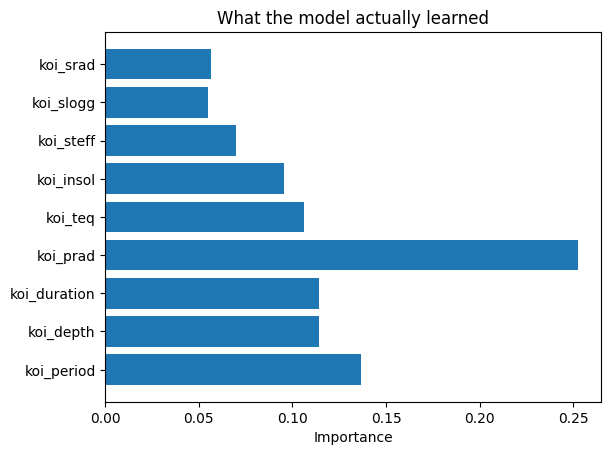

In [10]:
# See which features matter most
import matplotlib.pyplot as plt

importances = model.feature_importances_
plt.barh(features, importances)
plt.xlabel('Importance')
plt.title('What the model actually learned')
plt.show()

In [11]:
# Add more powerful features from the catalog
features_v2 = [
    # Original features
    'koi_period', 'koi_depth', 'koi_duration',
    'koi_prad', 'koi_teq', 'koi_insol',
    'koi_steff', 'koi_slogg', 'koi_srad',

    # New powerful features
    'koi_impact',        # impact parameter - geometry of transit
    'koi_incl',          # orbital inclination
    'koi_dor',           # planet-star distance ratio
    'koi_count',         # number of planets in system
    'koi_steff_err1',    # stellar temperature uncertainty
    'koi_srho',          # stellar density - very powerful
    'koi_fittype',       # what kind of fit was used
    'koi_score',         # disposition score from NASA
]

X2 = df_clean[features_v2].copy()

# Drop non-numeric and missing
X2 = X2.select_dtypes(include='number').dropna()
y2 = y_clean[X2.index]

print(f"Dataset shape: {X2.shape}")
print(f"Features: {list(X2.columns)}")

Dataset shape: (6539, 16)
Features: ['koi_period', 'koi_depth', 'koi_duration', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_steff', 'koi_slogg', 'koi_srad', 'koi_impact', 'koi_incl', 'koi_dor', 'koi_count', 'koi_steff_err1', 'koi_srho', 'koi_score']


In [12]:
# Split data
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Train with more trees this time
model2 = RandomForestClassifier(n_estimators=200, random_state=42)
model2.fit(X_train2, y_train2)

# Test it
y_pred2 = model2.predict(X_test2)
print(classification_report(y_test2, y_pred2,
      target_names=['False Positive', 'Confirmed Planet']))

                  precision    recall  f1-score   support

  False Positive       0.99      0.99      0.99       760
Confirmed Planet       0.98      0.98      0.98       548

        accuracy                           0.99      1308
       macro avg       0.99      0.99      0.99      1308
    weighted avg       0.99      0.99      0.99      1308



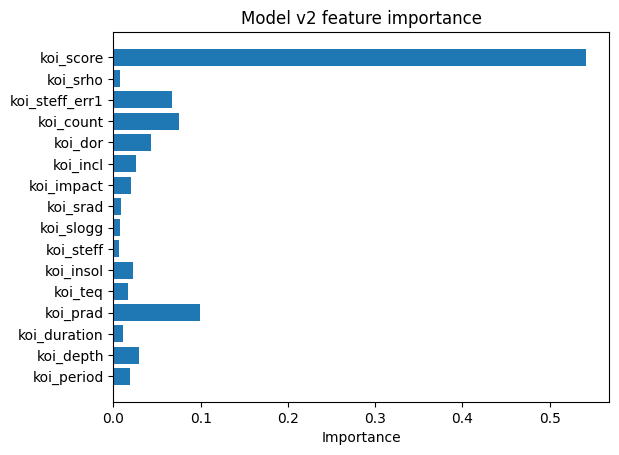

In [13]:
# Check feature importances for model2
importances2 = model2.feature_importances_
features_v2_numeric = list(X2.columns)

plt.barh(features_v2_numeric, importances2)
plt.xlabel('Importance')
plt.title('Model v2 feature importance')
plt.show()

In [14]:
# Remove koi_score - it's cheating
features_v3 = [col for col in X2.columns if col != 'koi_score']

X3 = X2[features_v3].copy()
y3 = y2.copy()

# Split and train
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

model3 = RandomForestClassifier(n_estimators=200, random_state=42)
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)
print(classification_report(y_test3, y_pred3,
      target_names=['False Positive', 'Confirmed Planet']))

                  precision    recall  f1-score   support

  False Positive       0.93      0.94      0.94       760
Confirmed Planet       0.91      0.91      0.91       548

        accuracy                           0.92      1308
       macro avg       0.92      0.92      0.92      1308
    weighted avg       0.92      0.92      0.92      1308



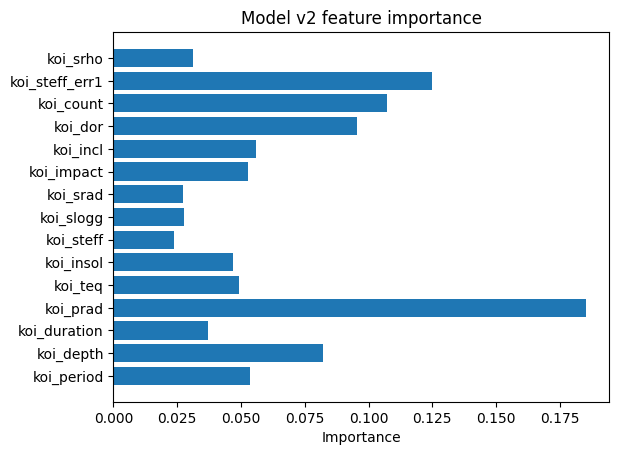

In [17]:
# Check feature importances for model2
importances3 = model3.feature_importances_
features_v3_numeric = list(X3.columns)

plt.barh(features_v3_numeric, importances3)
plt.xlabel('Importance')
plt.title('Model v2 feature importance')
plt.show()

In [18]:
# Get the CANDIDATE stars
candidates = df[df['koi_disposition'] == 'CANDIDATE']
X_candidates = candidates[features_v3].select_dtypes(include='number').dropna()

# Predict
predictions = model3.predict(X_candidates)
probabilities = model3.predict_proba(X_candidates)

# Add results back
X_candidates = X_candidates.copy()
X_candidates['prediction'] = predictions
X_candidates['confidence'] = probabilities[:, 1]

# Show most likely real planets
likely_planets = X_candidates[X_candidates['prediction'] == 1].sort_values(
    'confidence', ascending=False)

print(f"Candidates predicted as planets: {len(likely_planets)}")
print(likely_planets[['koi_prad', 'koi_period', 'confidence']].head(20))

Candidates predicted as planets: 828
      koi_prad  koi_period  confidence
4124      1.07    5.467551         1.0
4113      1.60   10.301485         1.0
304       1.94    9.617314         1.0
1404      2.88   17.791087         1.0
3945      1.17   16.534002         1.0
3645      1.60    7.664629         1.0
3624      0.99    8.029202         1.0
7728      2.09   11.818729         1.0
7289      1.98   17.236085         1.0
2847      1.98   13.251121         1.0
2909      1.85   44.433726         1.0
5174      2.24   12.501490         1.0
5061      1.61   15.061784         1.0
8870      1.44   17.718979         1.0
409       1.57   14.862308         1.0
5032      2.21   30.990300         1.0
5224      1.80   15.828383         1.0
7570      1.44    4.578344         1.0
7654      1.87    5.774511         1.0
2542      1.20    7.095639         1.0


In [20]:
# Reset to avoid index issues
candidates_clean = candidates[features_v3].select_dtypes(include='number').dropna()
candidates_with_ids = candidates.loc[candidates_clean.index]

# Predict
predictions = model3.predict(candidates_clean)
probabilities = model3.predict_proba(candidates_clean)

# Build result dataframe cleanly
result = candidates_with_ids[['kepid']].copy()
result['confidence'] = probabilities[:, 1]
result['predicted_planet'] = predictions
result['koi_prad'] = candidates_clean['koi_prad'].values
result['koi_period'] = candidates_clean['koi_period'].values

# Top 20 most confident planet predictions
top_candidates = result[result['predicted_planet'] == 1].sort_values(
    'confidence', ascending=False).head(20)

print("Top 20 candidate planets flagged by model:")
print(top_candidates[['kepid', 'koi_prad', 'koi_period', 'confidence']].to_string())

Top 20 candidate planets flagged by model:
         kepid  koi_prad  koi_period  confidence
4124   7107802      1.07    5.467551         1.0
4113   9896018      1.60   10.301485         1.0
304    9347899      1.94    9.617314         1.0
1404  11253711      2.88   17.791087         1.0
3945   7673192      1.17   16.534002         1.0
3645   6871071      1.60    7.664629         1.0
3624   4478168      0.99    8.029202         1.0
7728   3765917      2.09   11.818729         1.0
7289   5511659      1.98   17.236085         1.0
2847   8949925      1.98   13.251121         1.0
2909   9230021      1.85   44.433726         1.0
5174   7289338      2.24   12.501490         1.0
5061   9995771      1.61   15.061784         1.0
8870   9349757      1.44   17.718979         1.0
409    3554031      1.57   14.862308         1.0
5032   9967009      2.21   30.990300         1.0
5224   9230021      1.80   15.828383         1.0
7570   1432789      1.44    4.578344         1.0
7654   7289338      1.87  